In [ ]:
import polars as pl

df_calif = pl.read_excel(source="calificaciones.xlsx", sheet_name='2019' , schema_overrides={'cod_semestre': pl.String, 'cod_alumno': pl.Utf8})
df_rep = pl.read_excel(source="repitencias.xlsx", sheet_name='2019' , schema_overrides={'cod_semestre': pl.String, 'cod_alumno': pl.Utf8})
df_tutorias = pl.read_excel(source="tutorias.xlsx", sheet_name='2019' )

df_calif = df_calif.drop(['cod_plan'])
df_rep = df_rep.drop(['cod_plan'])
df_tutorias = df_tutorias.drop(['num_res_autoriza', 'cod_tipo_autorizacion'])

In [ ]:
df_features_calif = (
    df_calif
    .filter(pl.col("val_calific_final").is_between(0, 20))
    .with_columns( is_aprobado = pl.col("val_calific_final") >= 11 )
    .group_by("cod_alumno")
    .agg(
        promedio_calif = pl.col("val_calific_final").mean(),
        std_calif = pl.col("val_calific_final").std(),
        num_asignaturas = pl.col("cod_asignatura").n_unique(),
        tasa_aprobacion = pl.col("is_aprobado").mean(),
        num_semestres_activos = pl.col("cod_semestre").n_unique()
    )
)

df_features_calif

cod_alumno,promedio_calif,std_calif,num_asignaturas,tasa_aprobacion,num_semestres_activos
str,f64,f64,u32,f64,u32
"""18150362""",14.916667,2.712206,12,1.0,2
"""14120096""",14.0,1.414214,2,1.0,1
"""18110321""",13.142857,2.0327,13,0.928571,2
"""18020264""",14.636364,1.747726,11,1.0,1
"""17090100""",15.785714,2.455091,14,0.928571,2
…,…,…,…,…,…
"""16110192""",15.5,2.067058,12,1.0,2
"""16090072""",2.666667,3.204164,6,0.0,1
"""18030019""",14.8,2.20101,10,1.0,2


In [ ]:
df_features_rep = (
    df_rep
    .group_by("cod_alumno")
    .agg(
        total_repitencias = pl.col("num_rep").sum(),
        max_rep_asignatura = pl.col("num_rep").max()
    )
)

df_features_rep

cod_alumno,total_repitencias,max_rep_asignatura
str,i64,i64
"""10140129""",9,3
"""16130001""",1,1
"""18140077""",3,1
"""13160240""",3,1
"""14160308""",1,1
…,…,…
"""17110184""",1,1
"""16110005""",1,1
"""06150006""",6,2


In [ ]:
df_features_tutorias = (
    df_tutorias
    .group_by("cod_alumno")
    .agg( num_tutorias = pl.col("cod_alumno").count() )
)

df_features_tutorias

cod_alumno,num_tutorias
str,u32
"""08180043""",1
"""14090023""",1
"""13110111""",1
"""17020452""",2
"""891107 """,1
…,…
"""13140049""",1
"""13180002""",1
"""14200162""",1


In [ ]:
df_final = (
    df_features_calif
    .join(df_features_rep, on="cod_alumno", how="left")
    .join(df_features_tutorias, on="cod_alumno", how="left")
    .fill_null(0)
)

df_final

cod_alumno,promedio_calif,std_calif,num_asignaturas,tasa_aprobacion,num_semestres_activos,total_repitencias,max_rep_asignatura,num_tutorias
str,f64,f64,u32,f64,u32,i64,i64,u32
"""18150362""",14.916667,2.712206,12,1.0,2,0,0,0
"""14120096""",14.0,1.414214,2,1.0,1,0,0,0
"""18110321""",13.142857,2.0327,13,0.928571,2,1,1,0
"""18020264""",14.636364,1.747726,11,1.0,1,0,0,0
"""17090100""",15.785714,2.455091,14,0.928571,2,0,0,0
…,…,…,…,…,…,…,…,…
"""16110192""",15.5,2.067058,12,1.0,2,0,0,0
"""16090072""",2.666667,3.204164,6,0.0,1,0,0,0
"""18030019""",14.8,2.20101,10,1.0,2,0,0,0


In [ ]:
df_contexto = (
    df_calif
    .select(["cod_alumno", "cod_facultad", "cod_escuela"])
    .group_by("cod_alumno")
    .agg(
        facultad_principal = pl.col("cod_facultad").mode().cast(pl.Int32).first(),
        escuela_principal = pl.col("cod_escuela").mode().cast(pl.Int32).first()
    )
)

In [ ]:
df_final = df_final.join(df_contexto, on="cod_alumno", how="left")

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

df_pd = df_final.to_pandas()

features_df = df_pd.drop(columns=["cod_alumno"])

numeric_features = [
    'promedio_calif', 'std_calif', 'num_asignaturas', 'tasa_aprobacion',
    'num_semestres_activos', 'total_repitencias', 'max_rep_asignatura',
    'num_tutorias'
]
categorical_features = ['facultad_principal', 'escuela_principal']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough'
)

X_scaled = preprocessor.fit_transform(features_df)

In [ ]:
df = pd.DataFrame(X_scaled)
df

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.554454,0.140944,0.650093,0.605270,0.538693,-0.436718,-0.639131,-0.324183
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.282959,-0.658827,-1.879431,0.605270,-1.856346,-0.436718,-0.639131,-0.324183
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.029094,-0.277741,0.903045,0.311299,0.538693,-0.108838,0.542199,-0.324183
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.471435,-0.453330,0.397140,0.605270,-1.856346,-0.436718,-0.639131,-0.324183
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.811844,-0.017480,1.155997,0.311299,0.538693,-0.436718,-0.639131,-0.324183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27587,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.727223,-0.256571,0.650093,0.605270,0.538693,-0.436718,-0.639131,-0.324183
27588,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,-3.073698,0.444069,-0.867622,-3.510322,-1.856346,-0.436718,-0.639131,-0.324183
27589,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.519900,-0.174035,0.144188,0.605270,0.538693,-0.436718,-0.639131,-0.324183
27590,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.029094,-0.630559,1.155997,0.605270,0.538693,-0.108838,0.542199,-0.324183


In [ ]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 50):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

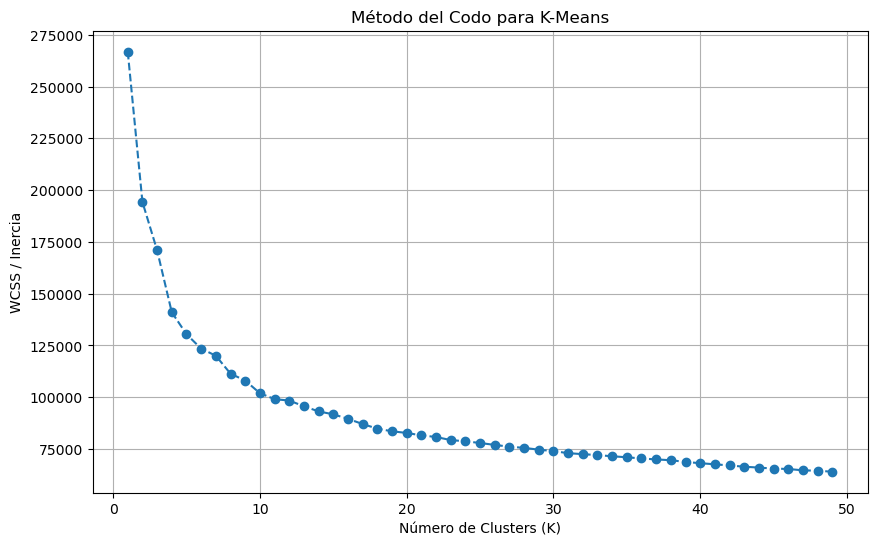

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, 50), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS / Inercia')
plt.grid(True)
plt.show()

In [ ]:
K_optimo = 5
kmeans_model = KMeans(n_clusters=K_optimo, random_state=42, n_init='auto')
clusters_kmeans = kmeans_model.fit_predict(X_scaled)

<Figure size 1000x800 with 0 Axes>

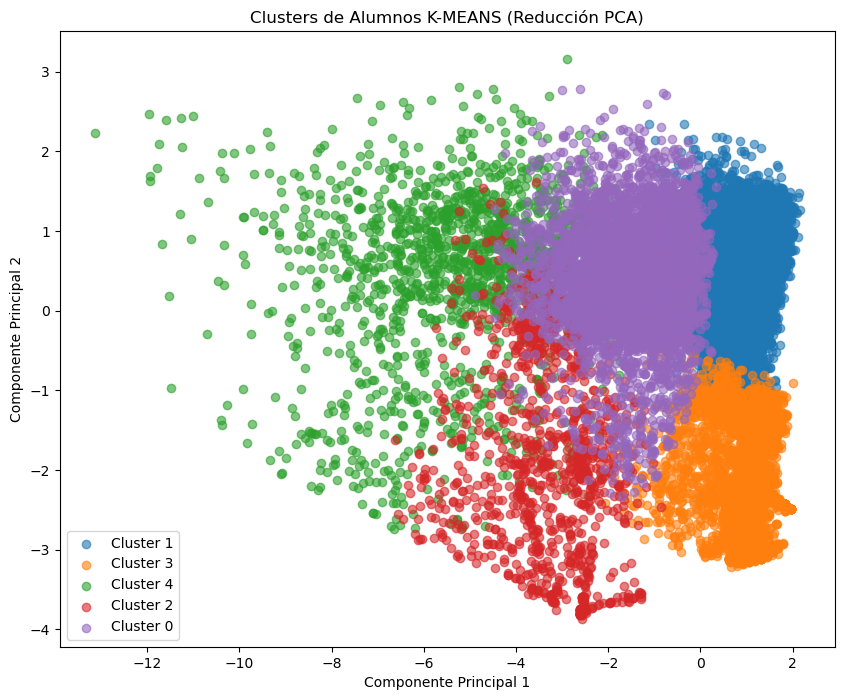

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2'])
df_pca['Cluster'] = clusters_kmeans

plt.figure(figsize=(10,8))

plt.figure(figsize=(10, 8))
for cluster in df_pca['Cluster'].unique():
    subset = df_pca[df_pca['Cluster'] == cluster]
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.title('Clusters de Alumnos K-MEANS (Reducción PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_avg_kmeans = silhouette_score(X_scaled, clusters_kmeans)
print(f"Coeficiente de Silueta (KMeans): {silhouette_avg_kmeans:.3f}")

Coeficiente de Silueta (KMeans): 0.265


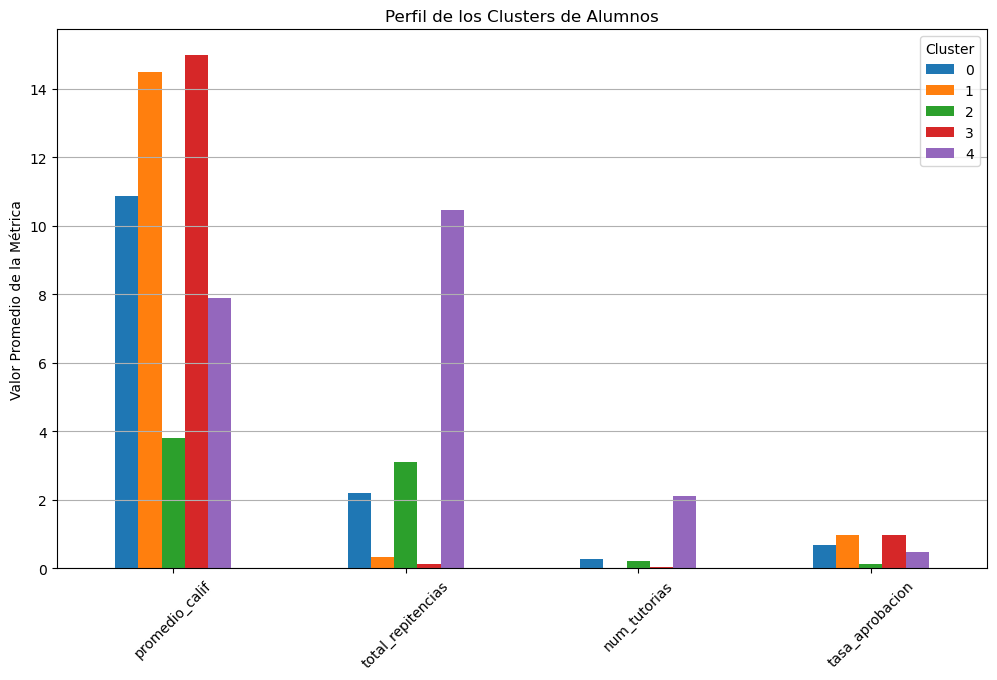

In [ ]:
df_pd['Cluster'] = clusters_kmeans

profile_df = df_pd.groupby('Cluster')[['promedio_calif', 'total_repitencias', 'num_tutorias', 'tasa_aprobacion']].mean()

profile_df.T.plot(kind='bar', figsize=(12, 7))
plt.title('Perfil de los Clusters de Alumnos')
plt.ylabel('Valor Promedio de la Métrica')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.grid(axis='y')
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

eps_optimo = 0.3 # 0.5
min_samples_optimo = 10

dbscan_model = DBSCAN(eps=eps_optimo, min_samples=min_samples_optimo)
clusters_dbscan = dbscan_model.fit_predict(X_scaled)

<Figure size 1000x800 with 0 Axes>

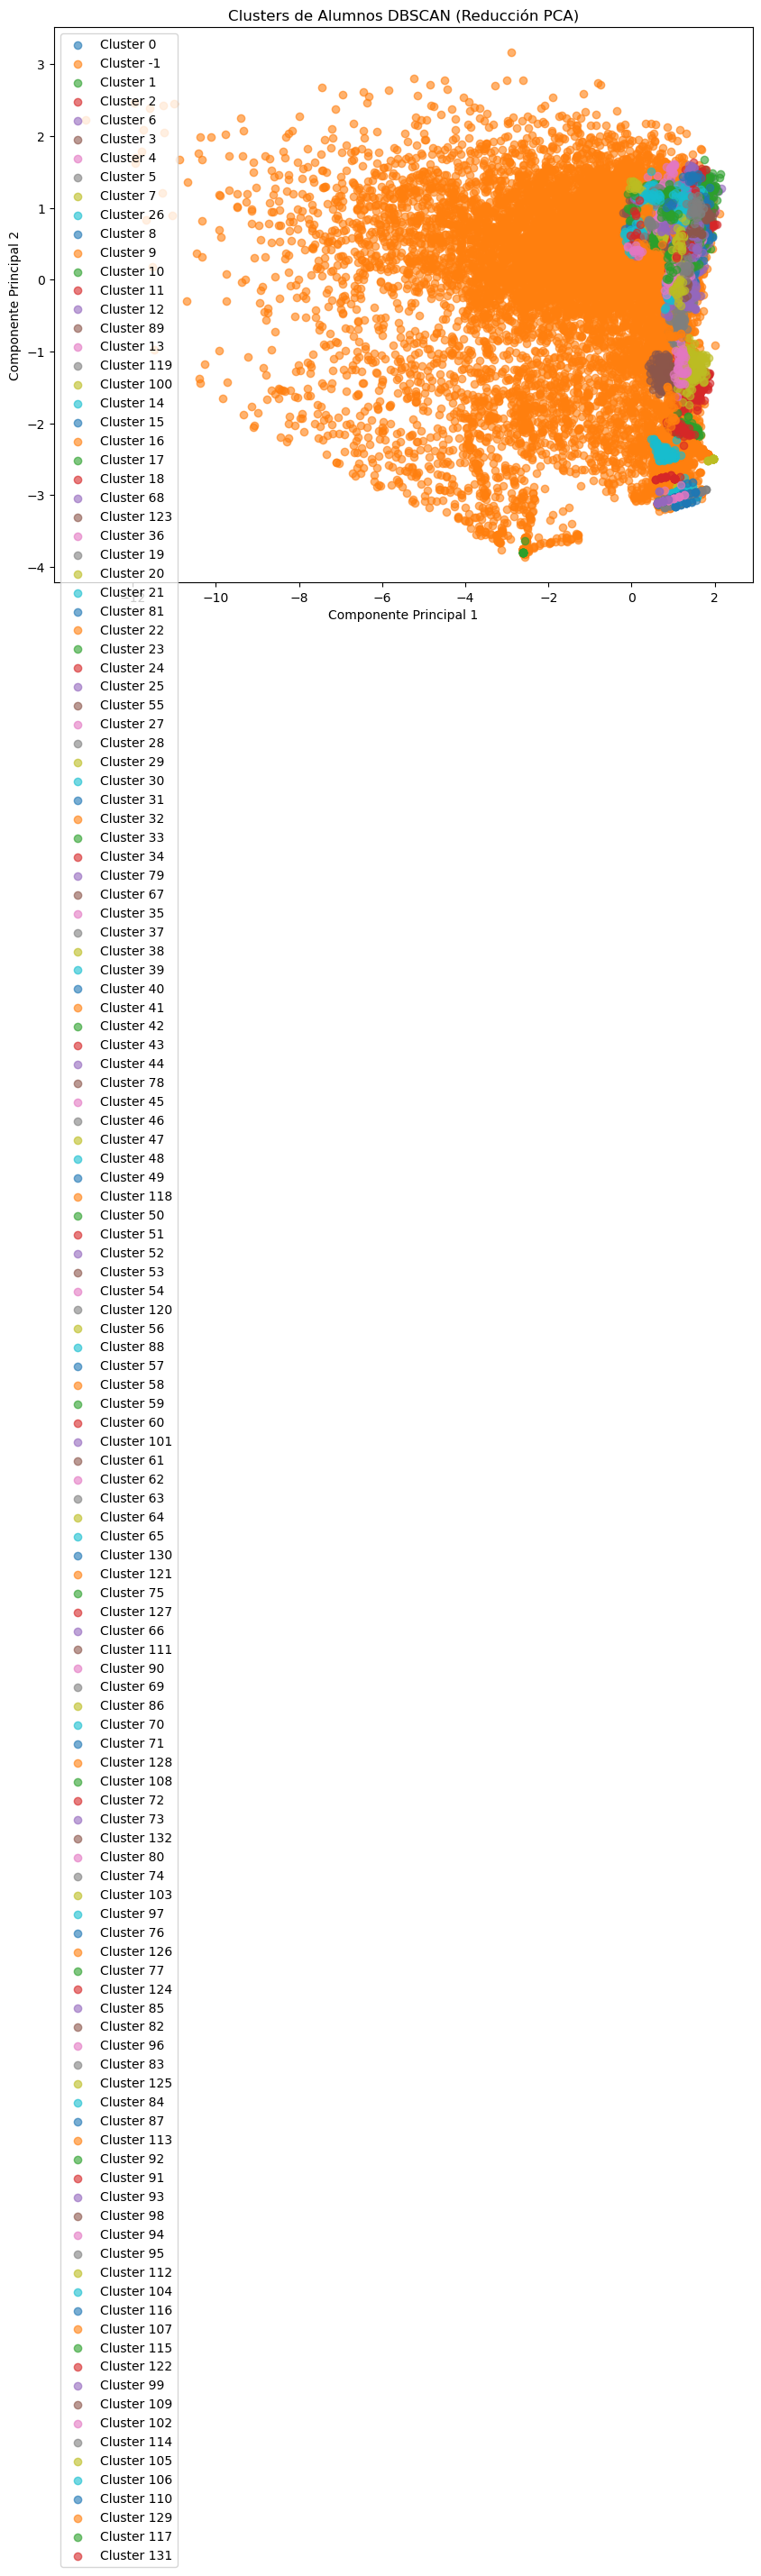

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2'])
df_pca['Cluster'] = clusters_dbscan

plt.figure(figsize=(10,8))

plt.figure(figsize=(10, 8))
for cluster in df_pca['Cluster'].unique():
    subset = df_pca[df_pca['Cluster'] == cluster]
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.title('Clusters de Alumnos DBSCAN (Reducción PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.show()

In [ ]:
non_noise_indices = clusters_dbscan != -1
if np.unique(clusters_dbscan[non_noise_indices]).size > 1:
    silhouette_avg_dbscan = silhouette_score(
        X_scaled[non_noise_indices],
        clusters_dbscan[non_noise_indices]
    )
    print(f"Coeficiente de Silueta (DBSCAN - sin ruido): {silhouette_avg_dbscan:.3f}")
else:
    print("DBSCAN no encontró suficientes clusters (>1) para calcular la Silueta.")

Coeficiente de Silueta (DBSCAN - sin ruido): 0.519
